# 🌬️🌧️🔥 Land Surface Model Variables Analysis
## Step 4: Climatic Variables + Land Cover — Biswas et al.-Aligned Feature Set — India (2000–2022)

**Extends:** FLDAS_NOAH01_C_GL_M.001 (Noah Land Surface Model, MERRA-2 + CHIRPS forced), monthly, 0.1°,
plus the ESA CCI/C3S LCCS land-cover archive already used by Step 1 / Step 6.
**Data:** `FLDAS_NOAH01_C_GL_M.A<YYYYMM>.001.nc`, one file per month (266 months), already downloaded into this folder
**Study period:** 1 Nov 2000 – 15 Dec 2022 — **matches Step 1 (fire), Step 2 (NDVI), Step 3 (LST) and Step 6 (integration) exactly**

> **v2 methodology (2026-09-25).** This notebook was updated to the corrected ("v2") feature
> definitions from the end-to-end methodology audit. See `results/FULL_METHODOLOGY_AUDIT.md`
> (project root, section *"Step 9 — Climate and land cover"*) and the verified reference
> implementation in `results/code/recalc_02_fldas.py`, `recalc_03_lulc.py` and `trend_stats.py`.
> What changed from the v1 notebook, and why:
>
> 1. **Model features are now climatological *levels*, not anomaly means.** v1 exported
>    `*_anomaly_mean`, the mean over all months of `x - clim_2001_2020`. The baseline-month
>    anomalies sum to exactly zero for each calendar month. That mean therefore equals
>    *Σ(anomalies of the 26 out-of-baseline months) / n*, which is a degenerate feature: its
>    spatial std is 40–431× smaller than that of the level itself. v2 uses the **2001–2020
>    calendar-month climatology averaged over the 12 months** (the "level"). This is the
>    quantity comparable to Biswas et al. The anomaly identity is still printed below as a
>    diagnostic.
> 2. **Trends use the Seasonal Kendall test** (Hirsch, Slack & Smith 1982). It uses
>    tie-corrected variance and a continuity-corrected two-sided p (≥30 within-season pairs).
>    Each pixel also gets a Benjamini-Hochberg FDR q-value (Benjamini & Hochberg 1995;
>    Wilks 2006) and a seasonal Sen slope. v1 ran a plain Mann-Kendall test on the raw monthly
>    series. That test is invalid for strongly seasonal data: the seasonal cycle dominates S and
>    inflates the variance. **v1 concluded that the air-temperature trend was multiple-testing
>    noise (636 raw → 0 FDR-significant pixels). That result came from the invalid test and is
>    withdrawn.** Under Seasonal Kendall, 9,988 of 29,056 India pixels have an FDR-significant
>    air-temperature trend (2,368 warming / 7,620 cooling).
> 3. **Land cover is taken from the 2001 LCCS map** (before the label period), not 2020. The
>    2020 map lies inside the 2000–2022 fire-label window, so post-fire reclassification could
>    leak label information.
> 4. **Fire points map to the pixel that contains them** (`floor` on edge-based affine
>    coordinates). The v1 `round()` rule on edge-based coordinates shifted ~75% of points by
>    one pixel.
>
> Variable extraction and units are unchanged from v1; they were reproduced exactly in the audit.

---
### Biswas et al. variable coverage

This notebook covers the climatic and land-cover part of Biswas et al.'s 15-variable Table 3
set. NDVI and LST Day/Night come from Steps 2–3. Terrain and distance to roads/rail/water come
from Step 5.

| # | Variable | Source | v2 per-pixel features |
|---|--------|------------------|-------|
| 1 | Air Temperature (K) | `Tair_f_tavg` | level + Seasonal-Kendall τ |
| 2 | Wind Speed (m/s) | `Wind_f_tavg` | level + Seasonal-Kendall τ |
| 3 | Specific Humidity (kg/kg) | `Qair_f_tavg` | level + Seasonal-Kendall τ. **A full per-pixel feature** (a Biswas et al. Table 3 predictor, from the same source product they used), not only an input to RH |
| 4 | Precipitation (mm/month) | `Rainf_f_tavg` × 86400 × days-in-month | level + Seasonal-Kendall τ (the mm/h value, ×3600, is kept in the monthly CSV) |
| 5 | Soil Moisture 0–10 cm (kg/m²) | `SoilMoi00_10cm_tavg` × 0.1 m × 1000 | level + Seasonal-Kendall τ (the 0–200 cm profile is kept in the monthly CSV) |
| 6 | Net LW Radiation (W/m²) | `Lwnet_tavg` | level + Seasonal-Kendall τ |
| — | Relative Humidity (%) | Derived (Magnus formula from q, T, p) | level + Seasonal-Kendall τ (extra variable, not in Biswas et al.; kept alongside specific humidity) |
| 7 | Land Cover (22 classes) | ESA CCI LCCS **2001**, Level-1 parent codes | 22 fractional-cover bands (Step 11 below) |
| — | Fire Points (CSV) | Step 1 archive | fire-coincidence diagnostic only (not a feature) |

Burned area is not a Biswas et al. Table 3 predictor. Step 1 uses it for a validation analysis.

### What this step delivers

| # | Metric | Notes |
|---|--------|-------|
| 1 | Climatological level (2001–2020, mean of the 12 calendar-month means) | Model feature for all 7 variables |
| 2 | Seasonal Kendall τ, p, BH-FDR q, seasonal Sen slope | τ is a model feature. p, q and Sen slope are exported on the native grid. Both raw p<0.05 and FDR counts are reported |
| 3 | Fire coincidence | Are fire-affected pixel-months drier, windier, lower in humidity or lower in soil moisture? (diagnostic) |
| 4 | NDVI-grid reprojection | `rasterio.warp.reproject`, **bilinear** (FLDAS 0.1° → NDVI grid 0.01° is upsampling). The effective resolution stays ~11 km. |
| 5 | Land cover 22-class fractions (2001) | Per-pixel fractional cover of each of the 22 Level-1 LCCS classes, area-averaged onto the NDVI grid |

### Design notes

- FLDAS is **natively monthly** (one file = one month). Unlike MODIS LST's 8-day composites,
  no per-month aggregation is needed.
- FLDAS is **global** at 0.1° with `Y` ascending (south→north). It is cropped to an India
  bounding box and flipped to north-up (row 0 = north).
- The Seasonal Kendall and Sen statistics run in vectorised NumPy on the 29,056 India pixels
  of the native 0.1° grid. The code is the same unit-tested code as
  `results/code/trend_stats.py`. At this size the GPU is not needed; the CuPy detection cell is
  kept for consistency with the other steps.

---

## 📦 Step 0 — Install Required Libraries

Run once. `cupy-cuda12x` + the NVIDIA JIT-header packages enable GPU acceleration.
If CuPy fails to install/import, the pipeline automatically falls back to CPU (NumPy) --
still correct, just slower.

In [1]:
import subprocess, sys

packages = [
    "numpy", "pandas", "matplotlib", "geopandas", "tqdm",
    "rasterio", "pyogrio", "xarray", "netCDF4",
    # GPU acceleration (native Windows -- no WSL required)
    "cupy-cuda12x",
    "nvidia-cuda-runtime-cu12",
    "nvidia-cuda-nvrtc-cu12",
    "nvidia-cuda-nvcc-cu12",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print("Library installation complete.")


Library installation complete.


## 📚 Step 1 — Imports & GPU Detection

Same auto-detect / auto-fallback pattern as Step 3 (LST).

In [2]:
import os
import re
import time
import gc
import io
import shutil
import contextlib
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import xarray as xr
import netCDF4 as nc_lib
from pathlib import Path
from tqdm import tqdm
from scipy.special import erf as erf_cpu

warnings.filterwarnings("ignore")

# GPU detection (CuPy) -- falls back cleanly to NumPy if unavailable
GPU_AVAILABLE = False
gpu_name = "N/A"
erf_gpu = None
try:
    # Suppress CuPy's one-time optional-integration warm-up noise (see Step 3's LST
    # notebook for the same pattern) -- real GPU failures still raise normally below.
    from IPython.core.interactiveshell import InteractiveShell
    _orig_showtraceback = InteractiveShell.showtraceback
    InteractiveShell.showtraceback = lambda *a, **k: None
    try:
        with contextlib.redirect_stderr(io.StringIO()):
            import cupy as cp
            from cupyx.scipy.special import erf as erf_gpu
            _test = cp.array([1, 2, 3]) * 2      # forces JIT compile now, not mid-pipeline
            _ = cp.isin(_test, cp.array([2]))
    finally:
        InteractiveShell.showtraceback = _orig_showtraceback
    GPU_AVAILABLE = True
    cp.cuda.set_pinned_memory_allocator(None)   # project convention (avoids cudaErrorAlreadyMapped)
    gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    free_mem, total_mem = cp.cuda.Device(0).mem_info
    print("GPU acceleration ON")
    print(f"   Device : {gpu_name}")
    print(f"   VRAM   : {free_mem/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total")
except Exception as e:
    import numpy as cp   # alias so downstream code (cp.xxx) works unchanged on CPU
    erf_gpu = None
    print(f"GPU unavailable ({e})")
    print("   Falling back to CPU (NumPy). Pipeline will still run correctly, just slower.")

def to_host(arr):
    # Bring a cp array back to a plain NumPy array (no-op on CPU fallback)
    return cp.asnumpy(arr) if GPU_AVAILABLE else arr

# NOTE (v2): the Seasonal Kendall / Sen / BH-FDR statistics in Step 7 run in NumPy on the
# 29,056 India pixels of the native 0.1 deg grid (seconds per variable) -- the GPU is not
# required for this step; detection is kept only for consistency with the other notebooks.
print("\nAll libraries imported successfully!")

GPU acceleration ON
   Device : NVIDIA RTX PRO 4500 Blackwell
   VRAM   : 32.8 GB free / 34.2 GB total

All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [3]:
# ═══════════════════════════════════════════════════
#  CONFIGURE PATHS
# ═══════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
FLDAS_DIR = os.path.join(
    BASE_DIR,
    "FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)",
)
LST_ANALYSIS_DIR = os.path.join(BASE_DIR, "LST_analysis")

# Step 1 -- fire points (for the fire-coincidence check)
FIRE_CSV_PATH = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)",
                              "Forest_Fire_Outputs", "all_forest_fires_2000_2022.csv")

# Same India boundary as Step 1 / Step 3 / Step 6 (dissolved State boundary, EPSG:3857 fix)
BOUNDARY_SHP = os.path.join(LST_ANALYSIS_DIR, "India_State_Boundary.shp")

# NDVI pipeline's own grid -- the reference grid every other source is aligned onto
NDVI_RAW_DIR = os.path.join(BASE_DIR, "NDVI_DATA_INDIA_", "NDVI TIF File_INDIA")

# Step 1's LULC archive (ESA CCI/C3S LCCS, 300m) -- reused here for the 22-class breakdown
LULC_DIR = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)",
                         "Forest_Fire_Outputs", "lulc_extracted")
# v2: 2001 = pre-label-period map (same year as Step 6's forest_frac_baseline). v1 used 2020,
# which lies inside the 2000-2022 fire-label window (post-fire reclassification = leakage risk).
LULC_YEAR = 2001

OUTPUT_DIR = os.path.join(FLDAS_DIR, "FLDAS_Outputs")
NDVI_ALIGNED_DIR = os.path.join(OUTPUT_DIR, "NDVI_Aligned_GeoTIFFs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(NDVI_ALIGNED_DIR, exist_ok=True)

# v1 outputs superseded by v2 (anomaly-mean features, raw-series Mann-Kendall maps, 2020 land
# cover). If True, any such files still on disk are MOVED (never deleted) into
# FLDAS_Outputs/_superseded_v1/ so a downstream loader cannot silently pick up a stale
# v1 feature under its old name.
ARCHIVE_LEGACY_V1_OUTPUTS = True
LEGACY_V1_DIR = os.path.join(OUTPUT_DIR, "_superseded_v1")

# Study period -- matches Steps 1-3 and 5-7 exactly
STUDY_START_DATE = pd.Timestamp("2000-11-01")
STUDY_END_DATE = pd.Timestamp("2022-12-15")
CLIMATOLOGY_START = pd.Timestamp("2001-01-01")
CLIMATOLOGY_END = pd.Timestamp("2020-12-31")

# India bounding box (with buffer) -- cheap pre-crop of the global FLDAS grid before
# exact polygon masking
LON_MIN, LON_MAX = 67.0, 98.5
LAT_MIN, LAT_MAX = 5.0, 38.5

# Internal variable key -> exported file-name stem. The stems are the output contract Step 6
# keys on: {Stem}_level_on_NDVI_grid.tif and SeasonalKendall_tau_{Stem}_on_NDVI_grid.tif.
EXPORT_VARS = {
    "tair": "AirTemp", "qair": "SpecificHumidity", "rh": "RH", "wind": "Wind",
    "precip": "Precip", "lwnet": "NetLWRadiation", "soilm_surf": "SoilMoisture",
}
FDR_ALPHA = 0.05

print("Configuration loaded:")
print(f"   FLDAS_DIR    : {FLDAS_DIR}  (exists: {os.path.isdir(FLDAS_DIR)})")
print(f"   Fire archive : {FIRE_CSV_PATH}  (exists: {os.path.exists(FIRE_CSV_PATH)})")
print(f"   Boundary     : {BOUNDARY_SHP}  (exists: {os.path.exists(BOUNDARY_SHP)})")
print(f"   NDVI grid ref: {NDVI_RAW_DIR}  (exists: {os.path.isdir(NDVI_RAW_DIR)})")
print(f"   LULC archive : {LULC_DIR}  (exists: {os.path.isdir(LULC_DIR)})  -- year {LULC_YEAR}")
print(f"   Outputs      : {OUTPUT_DIR}")
print(f"   Study period : {STUDY_START_DATE.date()} to {STUDY_END_DATE.date()}")
print(f"   Climatology  : {CLIMATOLOGY_START.date()} to {CLIMATOLOGY_END.date()}")

Configuration loaded:
   FLDAS_DIR    : D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)  (exists: True)
   Fire archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   Boundary     : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   NDVI grid ref: D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI TIF File_INDIA  (exists: True)
   LULC archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\lulc_extracted  (exists: True)  -- year 2001
   Outputs      : D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs
   Study period : 2000-11-01 to 2022-12-15
   Climatology  : 2001-01-01 to 2020-12-31


## 📍 Step 3 — India Boundary

Same boundary and CRS fix as Step 1 / Step 3 (LST) / Step 5 (Integrated): this shapefile
ships without a `.prj`, but its raw coordinates are Web Mercator meters, not lon/lat.

In [4]:
print("Loading India boundary...")
india_boundary = gpd.read_file(BOUNDARY_SHP)
if india_boundary.crs is None:
    india_boundary = india_boundary.set_crs("EPSG:3857", allow_override=True)
india_boundary = india_boundary.to_crs("EPSG:4326")
india_geom = india_boundary.dissolve(by=None).geometry.iloc[0]
print(f"   Bounds: lon=[{india_geom.bounds[0]:.2f}, {india_geom.bounds[2]:.2f}], "
      f"lat=[{india_geom.bounds[1]:.2f}, {india_geom.bounds[3]:.2f}]")
print("\nIndia boundary ready")


Loading India boundary...


   Bounds: lon=[68.12, 97.41], lat=[6.75, 37.10]

India boundary ready


## 📂 Step 4 — Discover FLDAS Monthly Files

Scans `FLDAS_DIR` for `FLDAS_NOAH01_C_GL_M.A<YYYYMM>.001.nc`, parses the year/month from
the filename, and keeps files within the study period.

In [5]:
print("Scanning for FLDAS monthly files...")

date_re = re.compile(r"\.A(\d{4})(\d{2})\.001\.nc$")
fldas_files = []
for fp in Path(FLDAS_DIR).glob("FLDAS_NOAH01_C_GL_M.A??????.001.nc"):
    m = date_re.search(fp.name)
    if m:
        year, month = int(m.group(1)), int(m.group(2))
        fldas_files.append((year, month, fp))

df_index = pd.DataFrame(sorted(fldas_files), columns=["year", "month", "path"])
df_index["date"] = pd.to_datetime(dict(year=df_index.year, month=df_index.month, day=1))
print(f"   Files found: {len(df_index)}")

df_study = df_index[(df_index["date"] >= STUDY_START_DATE) & (df_index["date"] <= STUDY_END_DATE)].reset_index(drop=True)
print(f"   Within study period ({STUDY_START_DATE.date()} to {STUDY_END_DATE.date()}): {len(df_study)}")

if len(df_study) == 0:
    print("WARNING: No FLDAS files found in the study period!")
elif len(df_study) < 266:
    print(f"   NOTE: expected up to 266 months -- {266 - len(df_study)} still missing from the archive. "
          f"Run download_fldas_missing.py to fill the gap before trusting the trend/climatology results.")


Scanning for FLDAS monthly files...
   Files found: 266
   Within study period (2000-11-01 to 2022-12-15): 266


## 🔧 Step 5 — Read/Crop Pipeline

Helper functions to open one FLDAS monthly NetCDF via `xarray`, crop it to an India
bounding box (cheap -- avoids ever materializing the full global 1500×3600 grid), flip it
to north-up raster convention, mask the `-9999` fill value, and derive the full
Biswas-aligned variable set:

- **Wind speed** (m/s) — used as-is
- **Air temperature** (K) — `Tair_f_tavg`, used as-is
- **Specific humidity** (kg/kg) — `Qair_f_tavg`, used as-is
- **Precipitation** (mm/h and mm/month) — `Rainf_f_tavg` is a rate (kg m⁻² s⁻¹ ≡ mm/s water
  equivalent); ×3600 gives mm/h (Biswas et al.'s unit, kept in the monthly CSV), ×seconds-in-month
  gives the monthly total (mm/month), which is the unit of the v2 level and trend features
- **Soil moisture** (kg/m²) — `SoilMoi<depth>_tavg` is volumetric (m³/m³) per Noah's 4 depth
  layers (0-10/10-40/40-100/100-200cm); converting to a mass-per-area (kg/m²) multiplies
  each layer's fraction by its thickness (m) and water density (1000 kg/m³) -- the surface
  (0-10cm) layer is used as the headline feature, the summed 0-200cm profile as a bonus
- **Net LW radiation** (W/m²) — `Lwnet_tavg`, used as-is
- **Relative humidity** (%) — derived from specific humidity, air temperature and surface
  pressure (`Psurf_f_tavg`) via the Magnus (Bolton 1980) saturation-vapour-pressure
  approximation (extra variable, not in Biswas et al.)

In [6]:
# Noah LSM's 4 fixed soil-layer thicknesses (m), top to bottom
SOIL_LAYER_DEPTHS_M = [0.10, 0.30, 0.60, 1.00]
SOIL_LAYER_VARS = ["SoilMoi00_10cm_tavg", "SoilMoi10_40cm_tavg", "SoilMoi40_100cm_tavg", "SoilMoi100_200cm_tavg"]


def open_fldas_month(path):
    """Open one FLDAS monthly file, crop to India bbox, and flip to north-up."""
    ds = xr.open_dataset(path)
    sub = ds.sel(Y=slice(LAT_MIN, LAT_MAX), X=slice(LON_MIN, LON_MAX))
    sub = sub.isel(Y=slice(None, None, -1))  # Y is ascending (south->north) in FLDAS

    def get(varname):
        arr = sub[varname].values[0].astype(np.float32)
        return np.where(arr <= -9998.0, np.nan, arr)

    wind = get("Wind_f_tavg")          # m/s
    rainf = get("Rainf_f_tavg")        # kg m-2 s-1
    qair = get("Qair_f_tavg")          # kg/kg
    tair = get("Tair_f_tavg")          # K
    psurf = get("Psurf_f_tavg")        # Pa
    lwnet = get("Lwnet_tavg")          # W/m2
    soilmoi_layers = [get(v) for v in SOIL_LAYER_VARS]  # m3/m3, top to bottom

    lat = sub["Y"].values
    lon = sub["X"].values
    ds.close()
    return wind, rainf, qair, tair, psurf, lwnet, soilmoi_layers, lat, lon


def month_to_precip_mm(rainf, year, month):
    days = pd.Timestamp(year=year, month=month, day=1).days_in_month
    # Same operation order as the audit reference (results/code/recalc_02_fldas.py) so the
    # float32 values are bit-identical to it; units unchanged (kg m-2 s-1 -> mm/month).
    return rainf * 86400.0 * days


def rainf_to_mm_per_hour(rainf):
    return rainf * 3600.0


def soil_moisture_kgm2(soilmoi_layers):
    """Volumetric fraction (m3/m3) x layer thickness (m) x water density (1000 kg/m3)."""
    layers_kgm2 = [frac * depth * 1000.0 for frac, depth in zip(soilmoi_layers, SOIL_LAYER_DEPTHS_M)]
    surface_kgm2 = layers_kgm2[0]                     # 0-10cm, the headline feature
    total_kgm2 = sum(layers_kgm2)                      # 0-200cm profile, bonus
    return surface_kgm2, total_kgm2


def compute_relative_humidity(qair, tair_k, psurf_pa):
    tc = tair_k - 273.15
    es_hpa = 6.112 * np.exp((17.67 * tc) / (tc + 243.5))
    p_hpa = psurf_pa / 100.0
    e_hpa = (qair * p_hpa) / (0.622 + 0.378 * qair)
    rh = 100.0 * e_hpa / es_hpa
    return np.clip(rh, 0.0, 100.0)


print("Read/crop pipeline ready")


Read/crop pipeline ready


## 📊 Step 6 — Stream All Months, Build Monthly Arrays, Climatology and Levels (v2)

FLDAS is already monthly, so unlike Step 3 (LST) there is nothing to aggregate within a month.
Each file is read, cropped, masked to India and written directly into an `(n_months, H, W)`
array.

Then, for every variable:

- **Climatology**: the per-calendar-month mean over the **2001–2020** baseline, giving a
  `(12, H, W)` array.
- **Level (v2 model feature)**: the mean of those 12 calendar-month climatologies. This is the
  2001–2020 climatological annual mean, the quantity comparable to Biswas et al.
- **Monthly anomalies** `x − clim[month]`: used only for the national monthly CSV and the
  fire-coincidence diagnostic.

**Why the v1 `anomaly_mean` feature was dropped.** The baseline-month anomalies sum to zero
for each calendar month. The all-period mean anomaly therefore reduces to
`Σ(anomalies of the 26 months outside 2001–2020) / n_valid`: it carries only the 2000 and
2021–22 departures and contains no information about the 2001–2020 climate. The cell below
checks this identity numerically for every variable and prints the level-to-anomaly-mean
spatial-std ratio. See `results/FULL_METHODOLOGY_AUDIT.md`, "Step 9 — Climate and land cover".

In [7]:
if len(df_study) == 0:
    print("Cannot proceed: no FLDAS data for study period.")
else:
    t0 = time.time()

    first_wind, _, _, _, _, _, _, lat0, lon0 = open_fldas_month(df_study.iloc[0]["path"])
    H, W = first_wind.shape
    res_lon = float(lon0[1] - lon0[0])
    res_lat = float(lat0[0] - lat0[1])
    west = float(lon0[0] - res_lon / 2)
    north = float(lat0[0] + res_lat / 2)
    transform_ref = rasterio.transform.from_origin(west, north, res_lon, res_lat)
    crs_ref = "EPSG:4326"
    print(f"FLDAS India-cropped grid: {H} x {W} px, res={res_lon:.3f} deg")

    india_mask = rasterize(
        [(india_geom, 1)], out_shape=(H, W), transform=transform_ref, fill=0, dtype=np.uint8
    ).astype(bool)
    n_inside = int(india_mask.sum())
    print(f"India boundary mask: {n_inside:,} / {H*W:,} px ({100*n_inside/(H*W):.1f}%)")

    n_months = len(df_study)
    VAR_NAMES = ["wind", "precip", "precip_mmh", "qair", "rh", "tair", "lwnet", "soilm_surf", "soilm_total"]
    monthly = {v: np.full((n_months, H, W), np.nan, dtype=np.float32) for v in VAR_NAMES}

    ym_index = {(row.year, row.month): i for i, row in df_study.iterrows()}
    national_ts = {v: [] for v in VAR_NAMES}

    for i, row in tqdm(df_study.iterrows(), total=n_months, desc="Streaming FLDAS months"):
        wind, rainf, qair, tair, psurf, lwnet, soilmoi_layers, lat, lon = open_fldas_month(row["path"])
        precip = month_to_precip_mm(rainf, row["year"], row["month"])
        precip_mmh = rainf_to_mm_per_hour(rainf)
        rh = compute_relative_humidity(qair, tair, psurf)
        soilm_surf, soilm_total = soil_moisture_kgm2(soilmoi_layers)

        frame = {
            "wind": wind, "precip": precip, "precip_mmh": precip_mmh, "qair": qair, "rh": rh,
            "tair": tair, "lwnet": lwnet, "soilm_surf": soilm_surf, "soilm_total": soilm_total,
        }
        for v in VAR_NAMES:
            frame[v] = np.where(india_mask, frame[v], np.nan)
            monthly[v][i] = frame[v]
            national_ts[v].append(np.nanmean(frame[v]))

    years_arr = df_study["year"].values.astype(int)
    months_arr = df_study["month"].values.astype(int)
    base_mask = (years_arr >= CLIMATOLOGY_START.year) & (years_arr <= CLIMATOLOGY_END.year)
    print(f"\nClimatology baseline: {CLIMATOLOGY_START.year}-{CLIMATOLOGY_END.year} "
          f"({int(base_mask.sum())} months in, {int((~base_mask).sum())} months outside)")

    # ---- 2001-2020 calendar-month climatology (12, H, W) and v2 LEVEL (mean of the 12) ----
    clim, level = {}, {}
    for v in VAR_NAMES:
        c = np.full((12, H, W), np.nan, dtype=np.float32)
        for m in range(1, 13):
            c[m - 1] = np.nanmean(monthly[v][base_mask & (months_arr == m)], axis=0)
        clim[v] = c
        level[v] = np.nanmean(c, axis=0)

    # Monthly anomalies -- national monthly CSV + fire-coincidence diagnostic only (NOT features)
    anom = {v: monthly[v] - clim[v][months_arr - 1] for v in VAR_NAMES}

    # ---- Diagnostic: the v1 anomaly_mean feature is degenerate (see markdown above) ----
    print("\nDiagnostic -- v1 'anomaly_mean' identity (anomaly_mean == sum of out-of-baseline "
          "anomalies / n_valid) and level vs anomaly_mean spatial std:")
    anomaly_identity = {}
    for v, stem in EXPORT_VARS.items():
        a2 = anom[v].reshape(n_months, -1)
        am = np.nanmean(a2, axis=0)
        n_valid = np.sum(np.isfinite(a2), axis=0)
        outside = np.nansum(a2[~base_mask], axis=0) / np.maximum(n_valid, 1)
        ok = np.isfinite(am)
        err = float(np.nanmax(np.abs(am[ok] - outside[ok])))
        ratio = float(np.nanstd(level[v]) / max(np.nanstd(am), 1e-30))
        anomaly_identity[stem] = dict(max_abs_identity_error=err, level_std_over_anommean_std=ratio)
        print(f"   {stem:17s}: max |anomaly_mean - outside_sum/n| = {err:.3e}   "
              f"std(level)/std(anomaly_mean) = {ratio:,.0f}x")

    # Keep the original short names in scope (used throughout the rest of the notebook)
    monthly_wind, monthly_precip, monthly_qair, monthly_rh = monthly["wind"], monthly["precip"], monthly["qair"], monthly["rh"]
    monthly_tair, monthly_lwnet = monthly["tair"], monthly["lwnet"]
    monthly_soilm_surf, monthly_soilm_total, monthly_precip_mmh = monthly["soilm_surf"], monthly["soilm_total"], monthly["precip_mmh"]
    anom_wind, anom_precip, anom_rh = anom["wind"], anom["precip"], anom["rh"]
    anom_tair, anom_lwnet, anom_soilm_surf = anom["tair"], anom["lwnet"], anom["soilm_surf"]
    anom_qair = anom["qair"]
    national_wind_ts, national_precip_ts, national_rh_ts = national_ts["wind"], national_ts["precip"], national_ts["rh"]
    national_tair_ts, national_lwnet_ts = national_ts["tair"], national_ts["lwnet"]
    national_soilm_surf_ts, national_precip_mmh_ts = national_ts["soilm_surf"], national_ts["precip_mmh"]
    national_qair_ts = national_ts["qair"]

    elapsed = time.time() - t0
    print(f"\nStreamed {n_months} months in {elapsed:.1f} sec")
    print("National 2001-2020 climatological LEVELS (v2 features, India-pixel mean):")
    units = {"tair": "K", "qair": "kg/kg", "rh": "%", "wind": "m/s", "precip": "mm/month",
             "lwnet": "W/m2", "soilm_surf": "kg/m2 (0-10cm)"}
    for v, stem in EXPORT_VARS.items():
        print(f"   {stem:17s}: {np.nanmean(level[v][india_mask]):.6g} {units[v]}")

FLDAS India-cropped grid: 335 x 315 px, res=0.100 deg


India boundary mask: 29,056 / 105,525 px (27.5%)


Streaming FLDAS months:   0%|          | 0/266 [00:00<?, ?it/s]

Streaming FLDAS months:   0%|          | 1/266 [00:00<00:33,  7.87it/s]

Streaming FLDAS months:   1%|          | 2/266 [00:00<00:36,  7.32it/s]

...


Climatology baseline: 2001-2020 (240 months in, 26 months outside)



Diagnostic -- v1 'anomaly_mean' identity (anomaly_mean == sum of out-of-baseline anomalies / n_valid) and level vs anomaly_mean spatial std:
   AirTemp          : max |anomaly_mean - outside_sum/n| = 2.524e-05   std(level)/std(anomaly_mean) = 431x


   SpecificHumidity : max |anomaly_mean - outside_sum/n| = 1.180e-09   std(level)/std(anomaly_mean) = 112x
   RH               : max |anomaly_mean - outside_sum/n| = 5.347e-06   std(level)/std(anomaly_mean) = 67x


   Wind             : max |anomaly_mean - outside_sum/n| = 4.335e-07   std(level)/std(anomaly_mean) = 67x
   Precip           : max |anomaly_mean - outside_sum/n| = 4.387e-05   std(level)/std(anomaly_mean) = 40x


   NetLWRadiation   : max |anomaly_mean - outside_sum/n| = 8.550e-06   std(level)/std(anomaly_mean) = 67x
   SoilMoisture     : max |anomaly_mean - outside_sum/n| = 2.641e-06   std(level)/std(anomaly_mean) = 63x

Streamed 266 months in 44.6 sec
National 2001-2020 climatological LEVELS (v2 features, India-pixel mean):
   AirTemp          : 296.112 K
   SpecificHumidity : 0.0105197 kg/kg
   RH               : 52.3332 %
   Wind             : 4.47777 m/s
   Precip           : 94.3498 mm/month
   NetLWRadiation   : -84.9573 W/m2
   SoilMoisture     : 26.3689 kg/m2 (0-10cm)


## 📈 Step 7 — Temporal Trend Analysis (Seasonal Kendall τ + BH-FDR + seasonal Sen slope, v2)

**Test.** Seasonal Kendall (Hirsch, Slack & Smith 1982, *Water Resour. Res.* 18:107). The
Mann-Kendall S statistic is computed *within* each calendar month across years, and the 12
values are summed. The variance uses the standard tie correction. The two-sided p comes from
the continuity-corrected normal approximation and is only reported when there are ≥30
within-season pairs. τ_SK = S / Σ_m C(n_m, 2).

**Multiple testing.** Benjamini-Hochberg FDR q-values (Benjamini & Hochberg 1995; Wilks 2006,
*J. Appl. Meteor. Climatol.* 45:1181) are computed over all valid India pixels of each map.
Both the raw p<0.05 counts and the FDR-corrected counts are printed and exported.

**Magnitude.** The seasonal Sen slope (Hirsch et al. 1982) is the median of all within-month
pairwise slopes, in units per year.

**Why not v1's test.** v1 ran Mann-Kendall on the raw monthly series. With a strong seasonal
cycle, pairs straddling different seasons dominate S, and the i.i.d. variance formula is
wrong, so the test is invalid. The v1 claim that the air-temperature trend was
"multiple-testing noise (636 raw → 0 FDR)" came from that test and is **withdrawn**. The audit
reference counts (FDR q<0.05, of 29,056 India pixels) are checked automatically below.

The functions below are copied verbatim from the unit-tested `results/code/trend_stats.py`.
They run in NumPy on the India pixels only; the pixels outside India are NaN anyway.

In [8]:
# ---------------------------------------------------------------------------------------------
# Trend statistics -- copied verbatim from results/code/trend_stats.py (unit-tested, used by the
# 2026-09-24/25 audit recalculation R2). NumPy only, NaN-aware. x arrays are (T, N).
# ---------------------------------------------------------------------------------------------
def _norm_p(z):
    return 2.0 * (1.0 - 0.5 * (1.0 + erf_cpu(np.abs(z) / np.sqrt(2.0))))


def mk_raw(x):
    """v1 definition (MK on the raw series, ties ignored). DIAGNOSTIC ONLY -- invalid under
    seasonality; kept solely to show why the v1 trend conclusions were withdrawn."""
    T = x.shape[0]
    S = np.zeros(x.shape[1], np.float64)
    for lag in range(1, T):
        d = x[lag:] - x[:-lag]
        S += np.nansum(np.sign(d), axis=0)
    n = np.sum(np.isfinite(x), axis=0).astype(np.float64)
    var = n * (n - 1) * (2 * n + 5) / 18.0
    z = np.where(S > 0, (S - 1) / np.sqrt(np.maximum(var, 1e-9)),
                 np.where(S < 0, (S + 1) / np.sqrt(np.maximum(var, 1e-9)), 0.0))
    with np.errstate(invalid="ignore", divide="ignore"):
        tau = np.where(n > 2, S / (n * (n - 1) / 2), np.nan)
    p = np.where(n >= 10, _norm_p(z), np.nan)
    return S, n, tau, p


def _tie_term(xm):
    """Sum over tie groups of t(t-1)(2t+5) per column; xm (Y, N) with NaNs."""
    out = np.zeros(xm.shape[1], np.float64)
    xs = np.sort(xm, axis=0)
    eq = (xs[1:] == xs[:-1]) & np.isfinite(xs[1:])
    run = np.zeros(xm.shape[1], np.float64)
    for k in range(eq.shape[0]):
        run = np.where(eq[k], run + 1, run)
        end = ~eq[k]
        t = run + 1
        out += np.where(end & (run > 0), t * (t - 1) * (2 * t + 5), 0.0)
        run = np.where(end, 0, run)
    t = run + 1
    out += np.where(run > 0, t * (t - 1) * (2 * t + 5), 0.0)
    return out


def seasonal_kendall(x, months):
    """Hirsch, Slack & Smith (1982). x: (T, N); months: (T,) 1..12.
    Returns S, tau_SK, z, p, n_pairs (p only where n_pairs >= 30)."""
    N = x.shape[1]
    S = np.zeros(N); V = np.zeros(N); NP = np.zeros(N)
    for m in range(1, 13):
        xm = x[months == m]
        Y = xm.shape[0]
        if Y < 2:
            continue
        Sm = np.zeros(N)
        for lag in range(1, Y):
            Sm += np.nansum(np.sign(xm[lag:] - xm[:-lag]), axis=0)
        n = np.sum(np.isfinite(xm), axis=0).astype(np.float64)
        Vm = (n * (n - 1) * (2 * n + 5) - _tie_term(xm)) / 18.0
        S += Sm; V += np.where(n >= 2, Vm, 0); NP += np.where(n >= 2, n * (n - 1) / 2, 0)
    z = np.where(S > 0, (S - 1) / np.sqrt(np.maximum(V, 1e-12)),
                 np.where(S < 0, (S + 1) / np.sqrt(np.maximum(V, 1e-12)), 0.0))
    with np.errstate(invalid="ignore", divide="ignore"):
        tau = np.where(NP > 0, S / NP, np.nan)
    p = np.where(NP >= 30, _norm_p(z), np.nan)
    return S, tau, z, p, NP


def seasonal_sen(x, months, years, chunk=20000):
    """Seasonal Sen slope: median of all within-calendar-month pairwise slopes (per year)."""
    N = x.shape[1]
    out = np.full(N, np.nan)
    pairs = []
    for m in range(1, 13):
        idx = np.where(months == m)[0]
        for i in range(len(idx)):
            for j in range(i + 1, len(idx)):
                pairs.append((idx[i], idx[j]))
    pi = np.array([p[0] for p in pairs]); pj = np.array([p[1] for p in pairs])
    dy = (years[pj] - years[pi]).astype(np.float64)
    for s in range(0, N, chunk):
        sl = (x[pj, s:s + chunk] - x[pi, s:s + chunk]) / dy[:, None]
        out[s:s + chunk] = np.nanmedian(sl, axis=0)
    return out


def bh_fdr(p):
    """Benjamini-Hochberg (1995) q-values for a 1-D array with NaNs."""
    q = np.full(p.shape, np.nan)
    ok = np.isfinite(p)
    pv = p[ok]
    n = pv.size
    if n == 0:
        return q
    o = np.argsort(pv)
    ranked = pv[o] * n / np.arange(1, n + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    qq = np.empty(n); qq[o] = np.minimum(ranked, 1.0)
    q[ok] = qq
    return q


# Audit reference (results/recalculated/R2_fldas/R2_report.json): FDR q<0.05 counts of 29,056 px
EXPECTED_SK_FDR = {"AirTemp": 9988, "SpecificHumidity": 26373, "RH": 21677, "Wind": 15322,
                   "Precip": 7387, "NetLWRadiation": 23831, "SoilMoisture": 21600}

if len(df_study) > 0:
    print("Computing Seasonal Kendall + BH-FDR + seasonal Sen slope on the India pixels (NumPy)...")
    t0 = time.time()
    india_idx = np.flatnonzero(india_mask.ravel())

    def _to_map(vec, dtype=np.float32):
        out = np.full(H * W, np.nan, dtype=np.float32)
        out[india_idx] = vec
        return out.reshape(H, W).astype(dtype)

    trend_results = {}
    for v, stem in EXPORT_VARS.items():
        tv = time.time()
        x = monthly[v].reshape(n_months, -1)[:, india_idx]           # (T, n_india) float32
        S_sk, tau_sk, z_sk, p_sk, npairs = seasonal_kendall(x, months_arr)
        q_sk = bh_fdr(p_sk)
        sen = seasonal_sen(x, months_arr, years_arr)
        _, _, tau_mk, p_mk = mk_raw(x)                                # v1 test, diagnostic only
        q_mk = bh_fdr(p_mk)
        sig_fdr = np.isfinite(q_sk) & (q_sk < FDR_ALPHA)
        sig_raw = np.isfinite(p_sk) & (p_sk < 0.05)
        trend_results[stem] = dict(
            tau=_to_map(tau_sk), p=_to_map(p_sk), q=_to_map(q_sk), sen=_to_map(sen),
            n_pairs=_to_map(npairs), sig_fdr=_to_map(sig_fdr.astype(np.float32)),
            n_valid_px=int(np.isfinite(p_sk).sum()),
            n_raw_p05=int(sig_raw.sum()),
            n_raw_p05_pos=int((sig_raw & (tau_sk > 0)).sum()), n_raw_p05_neg=int((sig_raw & (tau_sk < 0)).sum()),
            n_fdr=int(sig_fdr.sum()),
            n_fdr_pos=int((sig_fdr & (tau_sk > 0)).sum()), n_fdr_neg=int((sig_fdr & (tau_sk < 0)).sum()),
            n_pos=int((tau_sk > 0).sum()), n_neg=int((tau_sk < 0).sum()),
            tau_mean=float(np.nanmean(tau_sk)), tau_std=float(np.nanstd(tau_sk)),
            sen_median_per_year=float(np.nanmedian(sen)),
            level_national_mean=float(np.nanmean(level[v][india_mask])),
            v1_mk_raw_tau_mean=float(np.nanmean(tau_mk)),
            v1_mk_raw_n_p05=int(np.nansum(p_mk < 0.05)),
            v1_mk_raw_n_fdr=int(np.nansum(q_mk < FDR_ALPHA)),
        )
        print(f"   {stem:17s} done in {time.time()-tv:.1f} s")
        del x

    print(f"   Completed in {time.time()-t0:.1f} sec")

    print("\nSeasonal Kendall significance -- RAW p < 0.05 (uncorrected) vs BH-FDR q < 0.05 "
          "(the FDR mask is the one used downstream):")
    for stem, r in trend_results.items():
        exp = EXPECTED_SK_FDR.get(stem)
        chk = "matches audit R2" if exp == r["n_fdr"] else f"MISMATCH vs audit R2 ({exp:,})"
        print(f"   {stem:17s}: tested={r['n_valid_px']:,} | raw p<0.05={r['n_raw_p05']:,} "
              f"(+{r['n_raw_p05_pos']:,}/-{r['n_raw_p05_neg']:,}) -> FDR={r['n_fdr']:,} "
              f"(+{r['n_fdr_pos']:,}/-{r['n_fdr_neg']:,})  [{chk}]  "
              f"tau_SK mean={r['tau_mean']:+.3f}, Sen median={r['sen_median_per_year']:+.4g}/yr")

    print("\nDiagnostic only -- v1 Mann-Kendall on the RAW monthly series (invalid under seasonality):")
    for stem, r in trend_results.items():
        print(f"   {stem:17s}: raw p<0.05={r['v1_mk_raw_n_p05']:,} -> FDR={r['v1_mk_raw_n_fdr']:,} "
              f"(vs Seasonal Kendall FDR={r['n_fdr']:,})")

Computing Seasonal Kendall + BH-FDR + seasonal Sen slope on the India pixels (NumPy)...


   AirTemp           done in 7.2 s


   SpecificHumidity  done in 7.1 s


   RH                done in 7.2 s


   Wind              done in 8.0 s


   Precip            done in 8.0 s


   NetLWRadiation    done in 7.3 s


   SoilMoisture      done in 7.9 s
   Completed in 52.8 sec

Seasonal Kendall significance -- RAW p < 0.05 (uncorrected) vs BH-FDR q < 0.05 (the FDR mask is the one used downstream):
   AirTemp          : tested=28,813 | raw p<0.05=13,081 (+2,994/-10,087) -> FDR=9,988 (+2,368/-7,620)  [matches audit R2]  tau_SK mean=-0.040, Sen median=-0.00766/yr
   SpecificHumidity : tested=28,813 | raw p<0.05=26,502 (+26,502/-0) -> FDR=26,373 (+26,373/-0)  [matches audit R2]  tau_SK mean=+0.200, Sen median=+3.167e-05/yr
   RH               : tested=28,813 | raw p<0.05=22,416 (+22,120/-296) -> FDR=21,677 (+21,398/-279)  [matches audit R2]  tau_SK mean=+0.171, Sen median=+0.1826/yr
   Wind             : tested=28,813 | raw p<0.05=17,953 (+3,166/-14,787) -> FDR=15,322 (+2,756/-12,566)  [matches audit R2]  tau_SK mean=-0.062, Sen median=-0.009184/yr
   Precip           : tested=28,813 | raw p<0.05=11,092 (+9,990/-1,102) -> FDR=7,387 (+6,617/-770)  [matches audit R2]  tau_SK mean=+0.073, Sen median=+0/yr


## 🔥 Step 8 — Fire Coincidence (diagnostic)

This cell loads Step 1's extracted fire points and rasterizes them onto this notebook's own
FLDAS-cropped grid, using the grid's own affine transform. It then checks whether
fire-affected pixel-months run drier, windier or lower in humidity than the grid-wide
average, which is the expected fire-risk signature.

**Pixel assignment (v2).** Each point goes to the pixel that *contains* it:
`col = floor((lon − c) / a)`, `row = floor((lat − f) / e)`. Here `c, f` are the top-left
**edge** coordinates of the affine transform. The v1 `round()` rule on those edge-based
coordinates assigns a point to the nearest pixel *corner*, not the containing pixel. It
shifted ~75% of points by one row and/or column. The cell prints the displacement count
for this grid as a check.

In [9]:
if len(df_study) > 0:
    print("Loading forest fire points (Step 1 output)...")
    df_fire = pd.read_csv(FIRE_CSV_PATH, usecols=["latitude", "longitude", "acq_date", "year", "month"])
    print(f"   Loaded {len(df_fire):,} fire points")

    a, b, c, d, e, f = transform_ref[:6]
    fire_lon = df_fire["longitude"].values
    fire_lat = df_fire["latitude"].values
    # v2: containing pixel (c, f are the top-left EDGE coordinates of the affine transform)
    fire_col = np.floor((fire_lon - c) / a).astype(np.int64)
    fire_row = np.floor((fire_lat - f) / e).astype(np.int64)
    # Diagnostic: how many points the v1 round() rule would have put in a different pixel
    legacy_col = np.round((fire_lon - c) / a).astype(np.int64)
    legacy_row = np.round((fire_lat - f) / e).astype(np.int64)
    n_displaced = int(np.sum((legacy_col != fire_col) | (legacy_row != fire_row)))
    print(f"   v1 round() rule would have displaced {n_displaced:,} / {len(df_fire):,} points "
          f"({100*n_displaced/len(df_fire):.1f}%) by one pixel -- now fixed (floor = containing pixel)")

    in_bounds = (fire_row >= 0) & (fire_row < H) & (fire_col >= 0) & (fire_col < W)
    print(f"   In FLDAS grid bounds: {in_bounds.sum():,}  (excluded {int((~in_bounds).sum()):,})")

    fire_row, fire_col = fire_row[in_bounds], fire_col[in_bounds]
    fire_year = df_fire["year"].values[in_bounds]
    fire_month = df_fire["month"].values[in_bounds]

    fire_count_map = np.zeros((H, W), dtype=np.int32)
    np.add.at(fire_count_map, (fire_row, fire_col), 1)

    fire_t = np.array([ym_index.get((y, m), -1) for y, m in zip(fire_year, fire_month)])
    has_month = fire_t >= 0
    fire_monthly_count = np.zeros((n_months, H, W), dtype=np.int32)
    np.add.at(fire_monthly_count, (fire_t[has_month], fire_row[has_month], fire_col[has_month]), 1)

    fire_pm_mask = fire_monthly_count > 0
    precip_anom_fire = float(np.nanmean(anom_precip[fire_pm_mask]))
    precip_anom_all = float(np.nanmean(anom_precip))
    wind_anom_fire = float(np.nanmean(anom_wind[fire_pm_mask]))
    wind_anom_all = float(np.nanmean(anom_wind))
    rh_anom_fire = float(np.nanmean(anom_rh[fire_pm_mask]))
    rh_anom_all = float(np.nanmean(anom_rh))
    tair_anom_fire = float(np.nanmean(anom_tair[fire_pm_mask]))
    tair_anom_all = float(np.nanmean(anom_tair))
    soilm_anom_fire = float(np.nanmean(anom_soilm_surf[fire_pm_mask]))
    soilm_anom_all = float(np.nanmean(anom_soilm_surf))
    qair_anom_fire = float(np.nanmean(anom_qair[fire_pm_mask]))
    qair_anom_all = float(np.nanmean(anom_qair))

    print(f"\n   Precip anomaly at fire pixel-months     : {precip_anom_fire:+.1f} mm  (grid-wide: {precip_anom_all:+.1f} mm)")
    print(f"   Wind anomaly at fire pixel-months       : {wind_anom_fire:+.2f} m/s (grid-wide: {wind_anom_all:+.2f} m/s)")
    print(f"   RH anomaly at fire pixel-months         : {rh_anom_fire:+.1f} %   (grid-wide: {rh_anom_all:+.1f} %)")
    print(f"   Spec. hum. anomaly at fire pixel-months : {qair_anom_fire:+.2e} kg/kg (grid-wide: {qair_anom_all:+.2e} kg/kg)")
    print(f"   Air temp anomaly at fire pixel-months   : {tair_anom_fire:+.2f} K   (grid-wide: {tair_anom_all:+.2f} K)")
    print(f"   Soil moisture anomaly at fire pixel-mos.: {soilm_anom_fire:+.2f} kg/m2 (grid-wide: {soilm_anom_all:+.2f} kg/m2)")
    print("\nFire coincidence ready")

Loading forest fire points (Step 1 output)...


   Loaded 541,545 fire points
   v1 round() rule would have displaced 405,808 / 541,545 points (74.9%) by one pixel -- now fixed (floor = containing pixel)
   In FLDAS grid bounds: 541,545  (excluded 0)



   Precip anomaly at fire pixel-months     : -5.7 mm  (grid-wide: +0.7 mm)
   Wind anomaly at fire pixel-months       : +0.00 m/s (grid-wide: -0.01 m/s)
   RH anomaly at fire pixel-months         : -1.8 %   (grid-wide: +0.3 %)
   Spec. hum. anomaly at fire pixel-months : -2.70e-04 kg/kg (grid-wide: +4.46e-05 kg/kg)
   Air temp anomaly at fire pixel-months   : +0.29 K   (grid-wide: -0.01 K)
   Soil moisture anomaly at fire pixel-mos.: -0.48 kg/m2 (grid-wide: +0.13 kg/m2)

Fire coincidence ready


## 🗺️ Step 9 — Visualize Key Results

Generating summary plots...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_Summary_Analysis.png


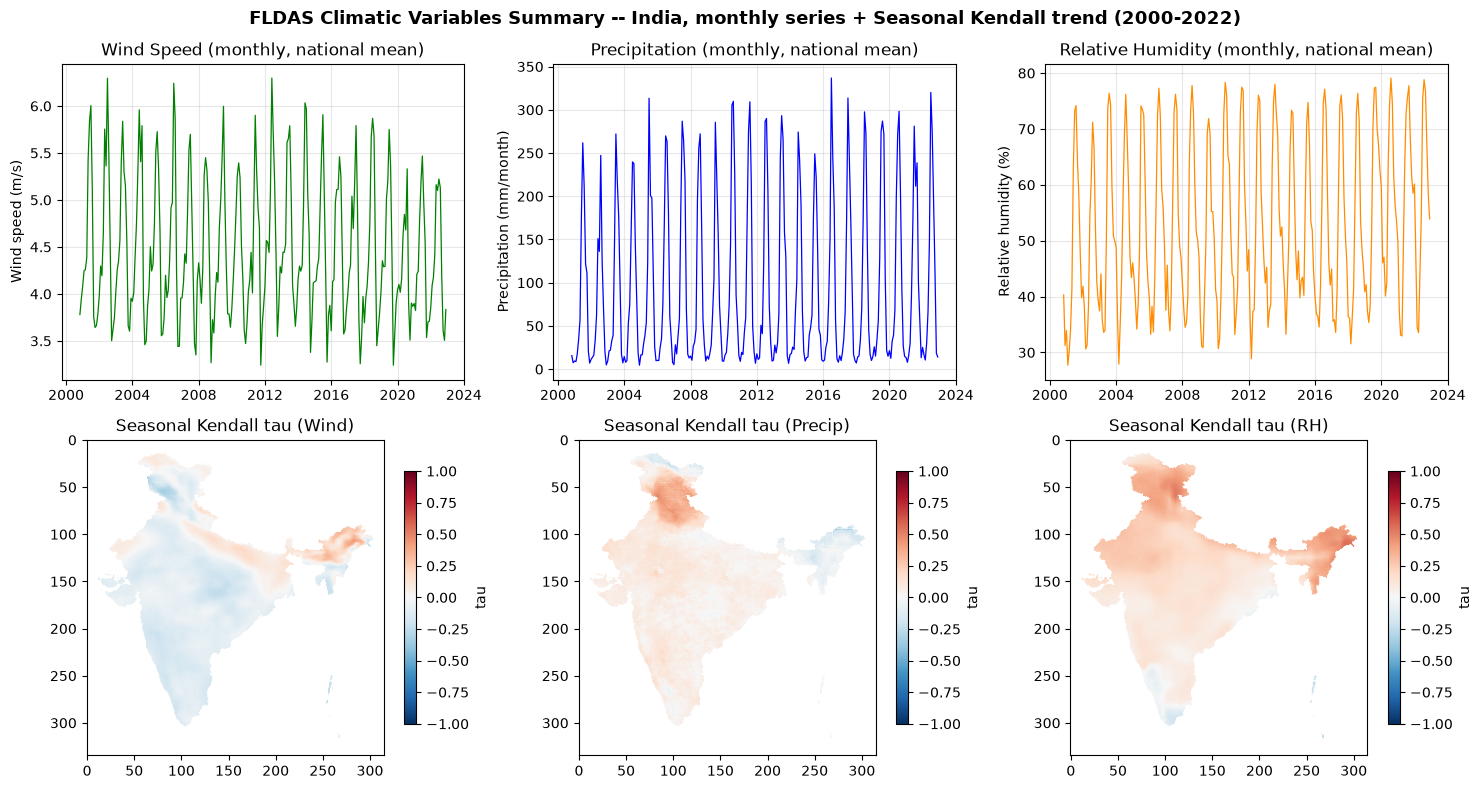

   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_Summary_Analysis_Additional.png


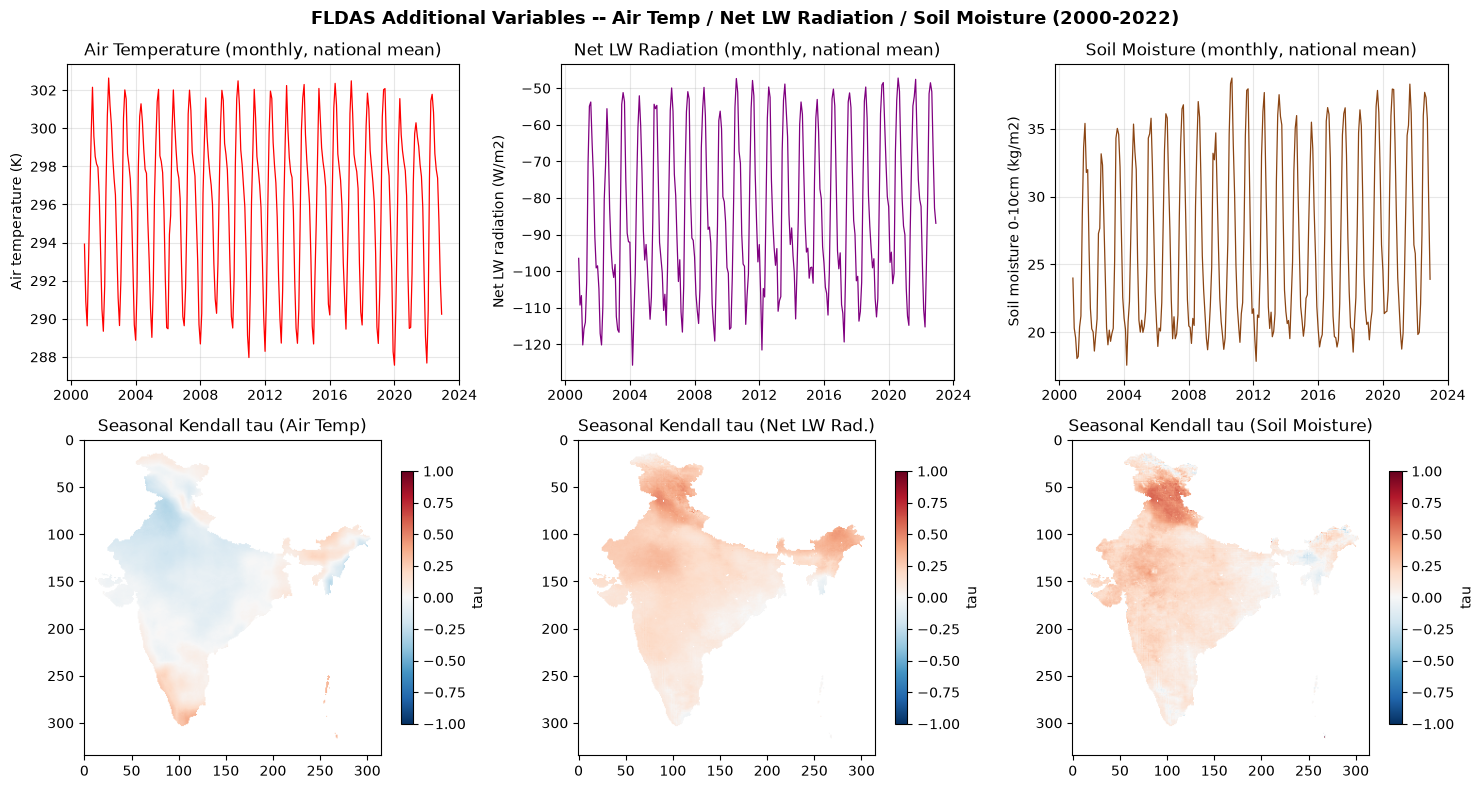

   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_Fire_Coincidence.png


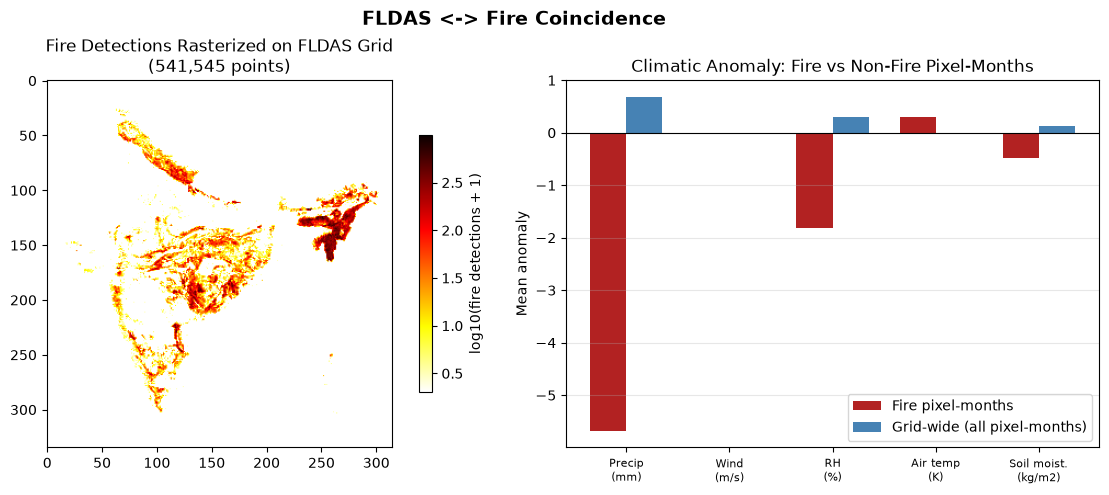

Visualizations complete


In [10]:
if len(df_study) > 0:
    print("Generating summary plots...")

    monthly_dates = df_study["date"].values

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("FLDAS Climatic Variables Summary -- India, monthly series + Seasonal Kendall trend (2000-2022)",
                 fontsize=13, fontweight="bold")

    ax = axes[0, 0]
    ax.plot(monthly_dates, national_wind_ts, "g-", linewidth=0.9)
    ax.set_ylabel("Wind speed (m/s)"); ax.set_title("Wind Speed (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(monthly_dates, national_precip_ts, "b-", linewidth=0.9)
    ax.set_ylabel("Precipitation (mm/month)"); ax.set_title("Precipitation (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes[0, 2]
    ax.plot(monthly_dates, national_rh_ts, "darkorange", linewidth=0.9)
    ax.set_ylabel("Relative humidity (%)"); ax.set_title("Relative Humidity (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    im = ax.imshow(trend_results["Wind"]["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Seasonal Kendall tau (Wind)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes[1, 1]
    im = ax.imshow(trend_results["Precip"]["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Seasonal Kendall tau (Precip)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes[1, 2]
    im = ax.imshow(trend_results["RH"]["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Seasonal Kendall tau (RH)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    plt.tight_layout()
    outfile = os.path.join(OUTPUT_DIR, "FLDAS_Summary_Analysis.png")
    plt.savefig(outfile, dpi=150, bbox_inches="tight")
    print(f"   Saved: {outfile}")
    plt.show()

    # --- Second figure: the new Biswas-aligned variables (temp, LW radiation, soil moisture) ---
    fig1b, axes1b = plt.subplots(2, 3, figsize=(15, 8))
    fig1b.suptitle("FLDAS Additional Variables -- Air Temp / Net LW Radiation / Soil Moisture (2000-2022)",
                   fontsize=13, fontweight="bold")

    ax = axes1b[0, 0]
    ax.plot(monthly_dates, national_tair_ts, "r-", linewidth=0.9)
    ax.set_ylabel("Air temperature (K)"); ax.set_title("Air Temperature (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes1b[0, 1]
    ax.plot(monthly_dates, national_lwnet_ts, "purple", linewidth=0.9)
    ax.set_ylabel("Net LW radiation (W/m2)"); ax.set_title("Net LW Radiation (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes1b[0, 2]
    ax.plot(monthly_dates, national_soilm_surf_ts, "saddlebrown", linewidth=0.9)
    ax.set_ylabel("Soil moisture 0-10cm (kg/m2)"); ax.set_title("Soil Moisture (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes1b[1, 0]
    im = ax.imshow(trend_results["AirTemp"]["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Seasonal Kendall tau (Air Temp)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes1b[1, 1]
    im = ax.imshow(trend_results["NetLWRadiation"]["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Seasonal Kendall tau (Net LW Rad.)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes1b[1, 2]
    im = ax.imshow(trend_results["SoilMoisture"]["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Seasonal Kendall tau (Soil Moisture)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    plt.tight_layout()
    outfile1b = os.path.join(OUTPUT_DIR, "FLDAS_Summary_Analysis_Additional.png")
    plt.savefig(outfile1b, dpi=150, bbox_inches="tight")
    print(f"   Saved: {outfile1b}")
    plt.show()

    # --- Third figure: fire coincidence ---
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    fig2.suptitle("FLDAS <-> Fire Coincidence", fontsize=14, fontweight="bold")

    ax = axes2[0]
    im = ax.imshow(np.where(fire_count_map > 0, np.log10(fire_count_map + 1), np.nan), cmap="hot_r")
    ax.set_title(f"Fire Detections Rasterized on FLDAS Grid\n({len(df_fire):,} points)")
    plt.colorbar(im, ax=ax, label="log10(fire detections + 1)", shrink=0.7)

    ax = axes2[1]
    labels = ["Precip\n(mm)", "Wind\n(m/s)", "RH\n(%)", "Air temp\n(K)", "Soil moist.\n(kg/m2)"]
    fire_vals = [precip_anom_fire, wind_anom_fire, rh_anom_fire, tair_anom_fire, soilm_anom_fire]
    all_vals = [precip_anom_all, wind_anom_all, rh_anom_all, tair_anom_all, soilm_anom_all]
    x = np.arange(len(labels)); width = 0.35
    ax.bar(x - width/2, fire_vals, width, label="Fire pixel-months", color="firebrick")
    ax.bar(x + width/2, all_vals, width, label="Grid-wide (all pixel-months)", color="steelblue")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8); ax.set_ylabel("Mean anomaly")
    ax.set_title("Climatic Anomaly: Fire vs Non-Fire Pixel-Months")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y"); ax.axhline(0, color="black", linewidth=0.8)

    plt.tight_layout()
    outfile2 = os.path.join(OUTPUT_DIR, "FLDAS_Fire_Coincidence.png")
    plt.savefig(outfile2, dpi=150, bbox_inches="tight")
    print(f"   Saved: {outfile2}")
    plt.show()

    print("Visualizations complete")


## 💾 Step 10 — Export Results (v2 output contract)

1. **`FLDAS_monthly_statistics_NDVI_aligned.csv`**: national monthly means and monthly
   anomalies, with join key `(year, month)`. The schema is unchanged from v1. A national
   monthly anomaly time series is a valid quantity; it is not the degenerate per-pixel
   anomaly mean.
2. **`FLDAS_trend_summary.csv`**: one row per variable with Seasonal Kendall τ, the raw
   p<0.05 counts **and** the BH-FDR counts (±), the Sen-slope median and the national level.
   It also has the v1 raw-series MK counts as a clearly labelled diagnostic.
3. **Native 0.1° grid** (`FLDAS_Outputs/`), per variable `{Var}`:
   - `{Var}_level.tif`
   - `SeasonalKendall_tau_{Var}.tif`, `SeasonalKendall_pvalue_{Var}.tif`,
     `SeasonalKendall_qvalue_FDR_{Var}.tif`, `SeasonalKendall_significant_FDR_{Var}.tif`
   - `SeasonalSen_slope_per_year_{Var}.tif`
   - `Fire_count_map.tif`
4. **NDVI grid** (`FLDAS_Outputs/NDVI_Aligned_GeoTIFFs/`, bilinear). These are the **model
   features** Step 6 loads:
   - `{Var}_level_on_NDVI_grid.tif`
   - `SeasonalKendall_tau_{Var}_on_NDVI_grid.tif`
   - `Fire_count_map_on_NDVI_grid.tif` (diagnostic)

`{Var}` ∈ AirTemp, SpecificHumidity, RH, Wind, Precip, NetLWRadiation, SoilMoisture.

The v1 `*_anomaly_mean*` layers and `MannKendall_*` maps are **no longer produced**. If
`ARCHIVE_LEGACY_V1_OUTPUTS` is set, any copies left on disk are moved (never deleted) into
`FLDAS_Outputs/_superseded_v1/`. A loader still pointing at the old names then fails
loudly instead of silently reading stale v1 features.

In [11]:
if len(df_study) > 0:
    print("Exporting results...")

    # ---- 0. Move superseded v1 outputs out of the way (never deleted) ----
    if ARCHIVE_LEGACY_V1_OUTPUTS:
        legacy_patterns = [
            (OUTPUT_DIR, "*_anomaly_mean.tif"), (OUTPUT_DIR, "*_climatology_annualmean.tif"),
            (OUTPUT_DIR, "MannKendall_*.tif"), (OUTPUT_DIR, "LandCover_22Class_Fractions_2020.tif"),
            (OUTPUT_DIR, "LandCover_22Class_NationalMeanFraction.png"),
            (NDVI_ALIGNED_DIR, "*_anomaly_mean_on_NDVI_grid.tif"), (NDVI_ALIGNED_DIR, "MannKendall_*.tif"),
        ]
        n_moved = 0
        for folder, pattern in legacy_patterns:
            for fp in Path(folder).glob(pattern):
                sub = os.path.relpath(folder, OUTPUT_DIR)
                dest_dir = os.path.join(LEGACY_V1_DIR, sub) if sub != "." else LEGACY_V1_DIR
                os.makedirs(dest_dir, exist_ok=True)
                shutil.move(str(fp), os.path.join(dest_dir, fp.name))
                n_moved += 1
        print(f"   Moved {n_moved} superseded v1 output file(s) into {LEGACY_V1_DIR}")

    # ---- 1. Monthly statistics CSV (join key: year, month) -- schema unchanged ----
    monthly_fire_totals = fire_monthly_count.reshape(n_months, -1).sum(axis=1)
    df_monthly_export = pd.DataFrame({
        "year": df_study["year"].values,
        "month": df_study["month"].values,
        "wind_mean": np.nanmean(monthly_wind, axis=(1, 2)),
        "precip_mm_mean": np.nanmean(monthly_precip, axis=(1, 2)),
        "precip_mmh_mean": np.nanmean(monthly_precip_mmh, axis=(1, 2)),
        "rh_mean": np.nanmean(monthly_rh, axis=(1, 2)),
        "tair_k_mean": np.nanmean(monthly_tair, axis=(1, 2)),
        "qair_kgkg_mean": np.nanmean(monthly_qair, axis=(1, 2)),
        "lwnet_wm2_mean": np.nanmean(monthly_lwnet, axis=(1, 2)),
        "soilm_surface_kgm2_mean": np.nanmean(monthly_soilm_surf, axis=(1, 2)),
        "soilm_total_kgm2_mean": np.nanmean(monthly_soilm_total, axis=(1, 2)),
        "wind_anom_mean": np.nanmean(anom_wind, axis=(1, 2)),
        "precip_anom_mean": np.nanmean(anom_precip, axis=(1, 2)),
        "rh_anom_mean": np.nanmean(anom_rh, axis=(1, 2)),
        "qair_anom_mean": np.nanmean(anom_qair, axis=(1, 2)),
        "tair_anom_mean": np.nanmean(anom_tair, axis=(1, 2)),
        "lwnet_anom_mean": np.nanmean(anom_lwnet, axis=(1, 2)),
        "soilm_surface_anom_mean": np.nanmean(anom_soilm_surf, axis=(1, 2)),
        "fire_detections": monthly_fire_totals,
    })
    monthly_csv = os.path.join(OUTPUT_DIR, "FLDAS_monthly_statistics_NDVI_aligned.csv")
    df_monthly_export.to_csv(monthly_csv, index=False)
    print(f"   Saved: {monthly_csv}  <- join to the NDVI/LST/fire monthly tables on (year, month)")

    # ---- 2. Trend summary -- Seasonal Kendall; raw p<0.05 AND BH-FDR counts both reported ----
    trend_summary = pd.DataFrame([
        {
            "variable": stem,
            "test": "Seasonal Kendall (Hirsch et al. 1982), tie-corrected, continuity-corrected, >=30 pairs",
            "level_2001_2020_national_mean": r["level_national_mean"],
            "sk_tau_mean": r["tau_mean"],
            "sk_tau_std": r["tau_std"],
            "n_increasing_pixels": r["n_pos"],
            "n_decreasing_pixels": r["n_neg"],
            "n_significant_increasing_pixels_raw_p05": r["n_raw_p05_pos"],
            "n_significant_decreasing_pixels_raw_p05": r["n_raw_p05_neg"],
            "n_significant_total_pixels_raw_p05": r["n_raw_p05"],
            "n_significant_increasing_pixels_fdr": r["n_fdr_pos"],
            "n_significant_decreasing_pixels_fdr": r["n_fdr_neg"],
            "n_significant_total_pixels_fdr": r["n_fdr"],
            "n_valid_pixels": r["n_valid_px"],
            "sen_slope_median_per_year": r["sen_median_per_year"],
            "anomaly_mean_identity_max_abs_error": anomaly_identity[stem]["max_abs_identity_error"],
            "level_std_over_anomaly_mean_std": anomaly_identity[stem]["level_std_over_anommean_std"],
            "DIAGNOSTIC_v1_raw_MK_n_p05_INVALID": r["v1_mk_raw_n_p05"],
            "DIAGNOSTIC_v1_raw_MK_n_fdr_INVALID": r["v1_mk_raw_n_fdr"],
        }
        for stem, r in trend_results.items()
    ])
    trend_file = os.path.join(OUTPUT_DIR, "FLDAS_trend_summary.csv")
    trend_summary.to_csv(trend_file, index=False)
    print(f"   Saved: {trend_file}  (Seasonal Kendall; raw p<0.05 AND FDR-corrected significance columns)")

    # ---- 3. Per-pixel GeoTIFFs on the native FLDAS (India-cropped) grid ----
    def save_geotiff(array_2d, name, out_dir, transform, crs, shape):
        out_path = os.path.join(out_dir, f"{name}.tif")
        prof = {
            "driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
            "dtype": "float32", "crs": crs, "transform": transform, "nodata": np.nan, "compress": "lzw",
        }
        with rasterio.open(out_path, "w", **prof) as dst:
            dst.write(array_2d.astype(np.float32), 1)
        return out_path

    native_layers = {}
    for v, stem in EXPORT_VARS.items():
        r = trend_results[stem]
        native_layers[f"{stem}_level"] = level[v]
        native_layers[f"SeasonalKendall_tau_{stem}"] = r["tau"]
        native_layers[f"SeasonalKendall_pvalue_{stem}"] = r["p"]
        native_layers[f"SeasonalKendall_qvalue_FDR_{stem}"] = r["q"]
        native_layers[f"SeasonalKendall_significant_FDR_{stem}"] = r["sig_fdr"]
        native_layers[f"SeasonalSen_slope_per_year_{stem}"] = r["sen"]
    native_layers["Fire_count_map"] = fire_count_map.astype(np.float32)
    for name, arr in native_layers.items():
        p = save_geotiff(arr, name, OUTPUT_DIR, transform_ref, crs_ref, (H, W))
        print(f"   Saved: {p}")

    # ---- 4. Reproject the v2 model features onto the NDVI pipeline's exact grid ----
    ndvi_ref_candidates = [f for f in sorted(Path(NDVI_RAW_DIR).glob("*_NDVI_*.tif")) if "reliability" not in f.name.lower()]

    if ndvi_ref_candidates:
        with rasterio.open(ndvi_ref_candidates[0]) as ndvi_ref:
            ndvi_transform = ndvi_ref.transform
            ndvi_crs = ndvi_ref.crs
            ndvi_shape = (ndvi_ref.height, ndvi_ref.width)

        def reproject_to_ndvi_grid(src_array):
            dst = np.full(ndvi_shape, np.nan, dtype=np.float32)
            reproject(
                source=np.ascontiguousarray(src_array.astype(np.float32)), destination=dst,
                src_transform=transform_ref, src_crs=crs_ref,
                dst_transform=ndvi_transform, dst_crs=ndvi_crs,
                src_nodata=np.nan, dst_nodata=np.nan,
                resampling=Resampling.bilinear,  # FLDAS (0.1deg) -> NDVI grid (0.01deg) is
                # upsampling. Bilinear interpolation does not recover genuine sub-grid detail;
                # FLDAS-derived features carry ~11km effective spatial resolution despite
                # being stored on the 1km analysis grid.
            )
            return dst

        aligned_layers = {}
        for v, stem in EXPORT_VARS.items():
            aligned_layers[f"{stem}_level_on_NDVI_grid"] = level[v]
            aligned_layers[f"SeasonalKendall_tau_{stem}_on_NDVI_grid"] = trend_results[stem]["tau"]
        aligned_layers["Fire_count_map_on_NDVI_grid"] = fire_count_map.astype(np.float32)  # diagnostic only

        for name, arr in aligned_layers.items():
            resampled = reproject_to_ndvi_grid(arr)
            p = save_geotiff(resampled, name, NDVI_ALIGNED_DIR, ndvi_transform, ndvi_crs, ndvi_shape)
            print(f"   Saved (NDVI grid): {p}")

        print(f"\n   NDVI-aligned outputs written to: {NDVI_ALIGNED_DIR}")
        print(f"   Shape now matches the NDVI pipeline's grid: {ndvi_shape}")
    else:
        print("   WARNING: No NDVI reference GeoTIFF found in NDVI_RAW_DIR -- skipped NDVI-grid reprojection")

    print(f"\nResults exported to {OUTPUT_DIR}")

Exporting results...
   Moved 13 superseded v1 output file(s) into D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\_superseded_v1


   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_monthly_statistics_NDVI_aligned.csv  <- join to the NDVI/LST/fire monthly tables on (year, month)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_trend_summary.csv  (Seasonal Kendall; raw p<0.05 AND FDR-corrected significance columns)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\AirTemp_level.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\SeasonalKendall_tau_AirTemp.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degre

   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\AirTemp_level_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\SeasonalKendall_tau_AirTemp_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\SpecificHumidity_level_on_NDVI_grid.tif


...

   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\NetLWRadiation_level_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\SeasonalKendall_tau_NetLWRadiation_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\SoilMoisture_level_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\SeasonalKendall_tau_SoilMoisture_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\Fire_count_map_on_NDVI_grid.tif

   NDVI-aligned outputs written to: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs
   Shape now matches the NDVI pipeline's grid: (3641, 3504)

Results exported to D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs


## 🗺️ Step 11 — Land Cover, 22-Class ESA CCI Level-1 Legend, **2001** (v2)

This step does not use FLDAS data. It reuses the ESA CCI/C3S LCCS archive that Step 1 reads
for its forest filter. Instead of collapsing everything to forest/non-forest, it keeps the
**full class breakdown**.

The raw LCCS legend has 38 codes: the base "tens" codes 10, 20, 30 … 220, plus finer
sub-variants such as 61/62 (closed/open canopy within 60) or 11/12 (herbaceous/tree-shrub
within rainfed cropland). Mapping each sub-variant to its parent
(`base_code = (code // 10) * 10`) gives exactly the **22 Level-1 LCCS classes**. This was
verified 2026-08-09 as the official Level-1 legend.

For each of the 22 classes, the step builds a binary mask at the archive's native 300 m
resolution. It then area-averages the mask onto the NDVI grid (`Resampling.average`,
finer→coarser). The result is 22 bands of continuous 0–1 fractional cover per NDVI pixel,
one per class. The fractions sum to ~1 per valid pixel.

**Year = 2001 (v2).** v1 used the 2020 map, which lies inside the 2000–2022 fire-label window.
Post-fire land-cover reclassification in later LCCS products is a known leakage route (same
reasoning as Step 6 keeping only `forest_frac_baseline` (2001)). The audit measured forest
change 2001→2020 of +0.019 at fire pixels vs +0.018 at non-fire forest pixels, so the
mechanism is weak here. The pre-period map is still the defensible choice for a static
covariate. Band names and order are unchanged (`LC22_{code}_{name}`); class 140
(lichens_and_mosses) is absent over India in 2001 and is an all-zero band. See
`results/FULL_METHODOLOGY_AUDIT.md`, "Step 9 — Climate and land cover".

Loading ESA CCI/C3S land cover for 2001 (v2: pre-label-period map)...


   Loaded: ESACCI-LC-L4-LCCS-Map-300m-P1Y-2001-v2.0.7cds.area-subset.37.5.98.6.67.5.nc  shape=(11340, 10980)


   21 of the 22 base classes present over this extent (absent -> all-zero band: [140])



Reclassifying to 22 base classes and computing per-pixel fractions on the NDVI grid (3641 x 3504)...


Reclassifying land-cover classes:   0%|          | 0/22 [00:00<?, ?it/s]

...

Reclassifying land-cover classes: 100%|██████████| 22/22 [00:31<00:00,  1.43s/it]

   22 class-fraction layers computed in 31.4 sec



   Top 5 classes by national mean fraction (2001, India-masked):
      LC22_10_cropland_rainfed                      35.49%
      LC22_20_cropland_irrigated                    21.16%
      LC22_60_tree_broadleaved_deciduous            7.80%
      LC22_130_grassland                            5.45%
      LC22_40_mosaic_natural_vegetation             4.97%


   Sum of the 22 fractions over India pixels: mean=1.0000



   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\LandCover_22Class_Fractions_2001.tif  (22 bands, one per class, NDVI grid)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\LandCover_22Class_NationalMeanFraction_2001.png


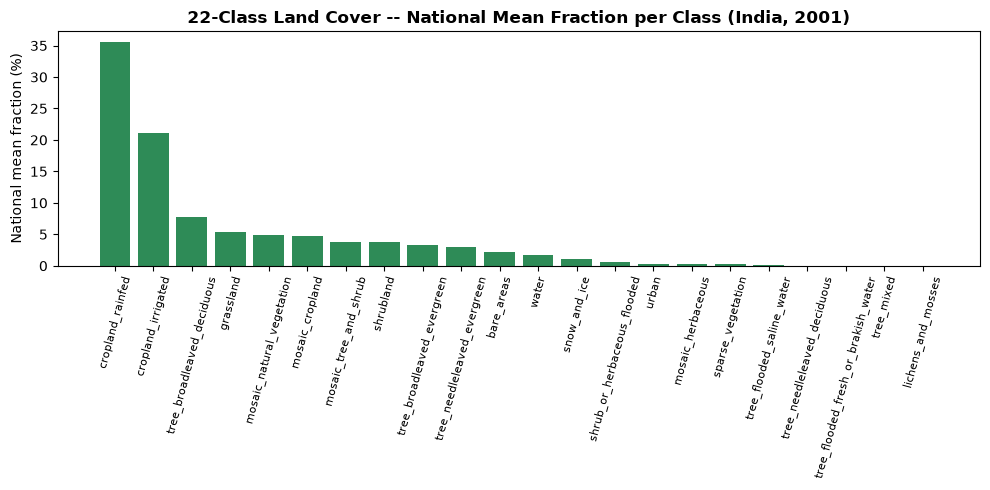


Land cover 22-class fractions ready


In [12]:
# The 22 base ESA CCI/C3S LCCS classes (sub-variants collapse to their parent code)
LCCS_22_CLASSES = {
    10: "cropland_rainfed", 20: "cropland_irrigated", 30: "mosaic_cropland",
    40: "mosaic_natural_vegetation", 50: "tree_broadleaved_evergreen",
    60: "tree_broadleaved_deciduous", 70: "tree_needleleaved_evergreen",
    80: "tree_needleleaved_deciduous", 90: "tree_mixed", 100: "mosaic_tree_and_shrub",
    110: "mosaic_herbaceous", 120: "shrubland", 130: "grassland",
    140: "lichens_and_mosses", 150: "sparse_vegetation",
    160: "tree_flooded_fresh_or_brakish_water", 170: "tree_flooded_saline_water",
    180: "shrub_or_herbaceous_flooded", 190: "urban", 200: "bare_areas",
    210: "water", 220: "snow_and_ice",
}


def find_lulc_file(year):
    candidates = sorted(Path(LULC_DIR).glob(f"*-{year}-*.nc"))
    if not candidates:
        raise FileNotFoundError(f"No LULC file found for year {year} in {LULC_DIR}")
    return candidates[0]


if os.path.isdir(LULC_DIR):
    print(f"Loading ESA CCI/C3S land cover for {LULC_YEAR} (v2: pre-label-period map)...")
    lulc_path = find_lulc_file(LULC_YEAR)
    with nc_lib.Dataset(lulc_path, 'r') as lds:
        lccs = np.asarray(lds.variables['lccs_class'][0, :, :]).astype(np.int32)
        lulc_lat = np.asarray(lds.variables['lat'][:])
        lulc_lon = np.asarray(lds.variables['lon'][:])
    if lulc_lat[0] < lulc_lat[-1]:          # enforce north-up (row 0 = north)
        lccs, lulc_lat = lccs[::-1], lulc_lat[::-1]
    print(f"   Loaded: {lulc_path.name}  shape={lccs.shape}")

    base_codes = np.where(lccs == 0, 0, (lccs // 10) * 10)
    present_codes = sorted(int(c) for c in np.unique(base_codes) if c != 0)
    absent_codes = [k for k in LCCS_22_CLASSES if k not in present_codes]
    print(f"   {len(present_codes)} of the 22 base classes present over this extent "
          f"(absent -> all-zero band: {absent_codes})")

    lulc_res_lon = float(lulc_lon[1] - lulc_lon[0])
    lulc_res_lat = float(lulc_lat[0] - lulc_lat[1])
    lulc_west = float(lulc_lon[0] - lulc_res_lon / 2)
    lulc_north = float(lulc_lat[0] + lulc_res_lat / 2)
    lulc_src_transform = rasterio.transform.from_origin(lulc_west, lulc_north, lulc_res_lon, lulc_res_lat)

    ndvi_ref_candidates_lc = [f for f in sorted(Path(NDVI_RAW_DIR).glob("*_NDVI_*.tif")) if "reliability" not in f.name.lower()]
    with rasterio.open(ndvi_ref_candidates_lc[0]) as ndvi_ref:
        lc_ndvi_transform = ndvi_ref.transform
        lc_ndvi_crs = ndvi_ref.crs
        lc_ndvi_shape = (ndvi_ref.height, ndvi_ref.width)
        lc_ndvi_profile = ndvi_ref.profile.copy()

    # The NDVI raster's own extent is a rectangular bounding box that includes surrounding
    # sea (Arabian Sea / Bay of Bengal) beyond India's actual coastline -- rasterize the
    # real India polygon onto this grid so summary stats aren't diluted by ocean pixels.
    india_mask_lc = rasterize(
        [(india_geom, 1)], out_shape=lc_ndvi_shape, transform=lc_ndvi_transform, fill=0, dtype=np.uint8
    ).astype(bool)

    print(f"\nReclassifying to 22 base classes and computing per-pixel fractions on the NDVI grid "
          f"({lc_ndvi_shape[0]} x {lc_ndvi_shape[1]})...")
    t0 = time.time()
    class_fraction_layers = {}
    for code, name in tqdm(LCCS_22_CLASSES.items(), desc="Reclassifying land-cover classes"):
        mask = (base_codes == code).astype(np.float32)
        dst = np.full(lc_ndvi_shape, np.nan, dtype=np.float32)
        reproject(
            source=mask, destination=dst,
            src_transform=lulc_src_transform, src_crs="EPSG:4326",
            dst_transform=lc_ndvi_transform, dst_crs=lc_ndvi_crs,
            src_nodata=None, dst_nodata=np.nan,
            resampling=Resampling.average,  # 300m source -> ~1km NDVI grid is downsampling
        )
        class_fraction_layers[f"LC22_{code}_{name}"] = dst
    print(f"   {len(class_fraction_layers)} class-fraction layers computed in {time.time()-t0:.1f} sec")

    lc_names = list(class_fraction_layers.keys())
    # Restrict the summary stats to actual India-polygon pixels (india_mask_lc), not the
    # NDVI raster's full rectangular extent, which includes surrounding ocean.
    national_mean_frac = {n: float(np.nanmean(np.where(india_mask_lc, class_fraction_layers[n], np.nan))) for n in lc_names}
    top5 = sorted(national_mean_frac.items(), key=lambda kv: kv[1], reverse=True)[:5]
    print(f"\n   Top 5 classes by national mean fraction ({LULC_YEAR}, India-masked):")
    for n, v in top5:
        print(f"      {n:45s} {100*v:.2f}%")
    frac_sum = np.nansum(np.stack([class_fraction_layers[n] for n in lc_names]), axis=0)
    print(f"   Sum of the 22 fractions over India pixels: mean={np.mean(frac_sum[india_mask_lc]):.4f}")
    del frac_sum

    lc_stack_path = os.path.join(OUTPUT_DIR, f"LandCover_22Class_Fractions_{LULC_YEAR}.tif")
    lc_profile = lc_ndvi_profile.copy()
    lc_profile.update(count=len(lc_names), dtype='float32', nodata=np.nan, compress='lzw')
    with rasterio.open(lc_stack_path, 'w', **lc_profile) as dst:
        for i, name in enumerate(lc_names):
            dst.write(class_fraction_layers[name].astype(np.float32), i + 1)
            dst.set_band_description(i + 1, name)
    print(f"\n   Saved: {lc_stack_path}  ({len(lc_names)} bands, one per class, NDVI grid)")

    fig, ax = plt.subplots(figsize=(10, 5))
    sorted_frac = sorted(national_mean_frac.items(), key=lambda kv: kv[1], reverse=True)
    ax.bar([n.split('_', 2)[-1] for n, v in sorted_frac], [100 * v for n, v in sorted_frac], color='seagreen')
    ax.set_ylabel('National mean fraction (%)')
    ax.set_title('22-Class Land Cover -- National Mean Fraction per Class (India, ' + str(LULC_YEAR) + ')', fontweight='bold')
    ax.tick_params(axis='x', rotation=75, labelsize=8)
    plt.tight_layout()
    lc_outfile = os.path.join(OUTPUT_DIR, f"LandCover_22Class_NationalMeanFraction_{LULC_YEAR}.png")
    plt.savefig(lc_outfile, dpi=150, bbox_inches='tight')
    print(f"   Saved: {lc_outfile}")
    plt.show()

    print("\nLand cover 22-class fractions ready")
else:
    print(f"WARNING: LULC_DIR not found ({LULC_DIR}) -- skipped land-cover step")

## ✅ Pipeline Complete — Alignment Summary (v2)

**Outputs** (in `FLDAS_Outputs/`):

| File | Contents |
|---|---|
| `FLDAS_monthly_statistics_NDVI_aligned.csv` | National monthly means and anomalies (wind, precip in mm/month and mm/h, RH, air temp, specific humidity, net LW radiation, soil moisture 0–10 cm and 0–200 cm) plus fire counts. Join key `(year, month)`, schema unchanged |
| `FLDAS_trend_summary.csv` | Per variable: Seasonal Kendall τ, raw p<0.05 **and** BH-FDR significant-pixel counts (±), Sen-slope median, national level, anomaly-mean identity check, v1 raw-MK counts (diagnostic, invalid) |
| `{Var}_level.tif`, `SeasonalKendall_{tau,pvalue,qvalue_FDR,significant_FDR}_{Var}.tif`, `SeasonalSen_slope_per_year_{Var}.tif`, `Fire_count_map.tif` | Native 0.1° grid |
| `NDVI_Aligned_GeoTIFFs/{Var}_level_on_NDVI_grid.tif`, `NDVI_Aligned_GeoTIFFs/SeasonalKendall_tau_{Var}_on_NDVI_grid.tif` | **v2 model features**, bilinear onto the NDVI grid (3641×3504, EPSG:4326) |
| `LandCover_22Class_Fractions_2001.tif` | 22-band GeoTIFF (band descriptions `LC22_{code}_{name}`), fractional cover per NDVI pixel from the **2001** LCCS map |
| `LandCover_22Class_NationalMeanFraction_2001.png` | Which classes dominate India's land surface in 2001 |

`{Var}` ∈ AirTemp, SpecificHumidity, RH, Wind, Precip, NetLWRadiation, SoilMoisture.

**No longer produced (v1, superseded):**
- `*_anomaly_mean*` (degenerate: equals Σ out-of-baseline anomalies / n)
- `MannKendall_*` (MK on the raw seasonal series is invalid)
- `LandCover_22Class_Fractions_2020.tif` (inside the label window)

Any leftover copies are moved to `FLDAS_Outputs/_superseded_v1/`.

**Downstream wiring (Step 6).** Step 6's `fldas_feature_files` dict and `LANDCOVER_22CLASS_TIF`
path must point at the v2 names above:
- 7 `*_level_on_NDVI_grid.tif` + 7 `SeasonalKendall_tau_*_on_NDVI_grid.tif`
- `LandCover_22Class_Fractions_2001.tif`

Band descriptions and band order of the land-cover stack are unchanged. The monthly CSV
merge on `(year, month)` is unchanged.

**Methodology reference:** `results/FULL_METHODOLOGY_AUDIT.md` (project root), "Step 9 —
Climate and land cover"; reference implementation `results/code/recalc_02_fldas.py`,
`recalc_03_lulc.py`, `trend_stats.py`; target numbers in
`results/recalculated/R2_fldas/R2_report.json` and `R3_lulc/R3_report.json`.